# Definindo o problema

Neste notebook, vamos implementar o Perceptron Clássico do zero usando apenas a biblioteca NumPy. O objetivo é entender o funcionamento básico de um neurônio artificial e o processo de atualização de pesos.

## Perceptron Clássico

Vamos lembrar que um perceptron é definido pela fórmula:

$$\hat{y_i} = sign(x_iw_i + b)$$

Na qual $sign$ é uma função definida por:

$$
f(x) =
\begin{cases}
1 & \text{se } x > 0 \\
-1 & \text{se } x < 0
\end{cases}
$$

Para descobrir os pesos do perceptron é necessário um processo iterativo, na qual podemos definir como:

$$w_i ← w_i + \eta*y*x_i$$

$$b ← b + \eta*y$$

### Importando as Bibliotecas Necessárias

In [ ]:
import numpy as np # Biblioteca fundamental para computação científica em Python. Permite a manipulação eficiente de arrays, matrizes e a realização de diversas operações matemáticas complexas.

class Perceptron:
  """
  Definição da classe Perceptron.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  def __init__(self, tamanho_input, learning_rate=0.1, epocas=100):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
    """
      # Primeiro definimos os pesos iniciais (vou definir como padrão 0 para todos)
    self.wi = np.zeros(tamanho_input)
    self.bias = 0
    self.learning_rate = learning_rate
    self.epocas = epocas # Isso só para facilitar o processo de parada

  def activation(self, x):
    """
    Função: activation
    Descrição: Aplica uma função de ativação
    """
    if(x > 0):
        return 1
    elif(x < 0):
        return -1
    elif(x == 0):
        return 0

  def predict(self, x):
    """
    Função: predict
    Descrição: Utiliza o estado atual do modelo (pesos treinados) para realizar predições sobre novos dados de entrada, retornando a classe ou valor estimado.
    """
    y_chapeu = self.activation(np.dot(self.wi, x) + self.bias)
    return y_chapeu

  def train(self, X, y):
    """
    Função: train
    Descrição: Implementa o laço principal de treinamento, onde o modelo ajusta seus parâmetros iterativamente com base no erro calculado sobre os dados.
    """
    for _ in range(self.epocas):
        erro = False
        for xi, yi in zip(X, y):
            y_chapeu = self.predict(xi)
            if y_chapeu != yi:
                self.wi = self.wi + self.learning_rate * (yi) * xi
                self.bias = self.bias + self.learning_rate * (yi)
                erro = True
        if not erro:
            break

In [ ]:
# Função abaixo faz o plot da linha de decisão do perceptron
import matplotlib.pyplot as plt # Principal biblioteca para criação de visualizações e gráficos em Python, essencial para analisar o comportamento do modelo e os dados.

def plot_decision_boundary(model, X, y, title):
  """
  Função: plot_decision_boundary
  Descrição: Função responsável por executar a lógica de plot_decision_boundary dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
  """
  plt.figure()
  plt.title(title)
  plt.xlabel("X1")
  plt.ylabel("X2")

  x_min, x_max = -0.1, 1.1
  y_min, y_max = -0.1, 1.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
  Z = np.zeros(xx.shape)
  for i in range(xx.shape[0]):
      for j in range(xx.shape[1]):
          Z[i, j] = model.predict(np.array([xx[i, j], yy[i, j]]))
  plt.contourf(xx, yy, Z, alpha=0.3)

  for xi, yi in zip(X, y):
      plt.scatter(xi[0], xi[1], color='red' if yi == -1 else 'blue')
  plt.show()

In [ ]:
# Dados para funções lógicas
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([-1, -1, -1, 1])  # AND
y_or = np.array([-1, 1, 1, 1])   # OR
y_xor = np.array([-1, 1, 1, -1])  # XOR


Perceptron para AND:
Entrada: [0 0], Saída: -1
Entrada: [0 1], Saída: -1
Entrada: [1 0], Saída: -1
Entrada: [1 1], Saída: 1


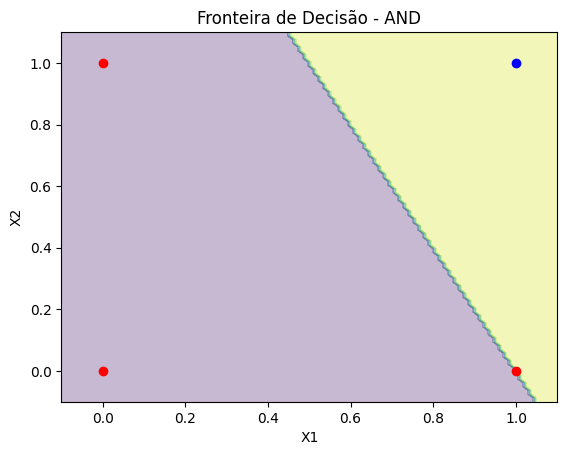


Perceptron para OR:
Entrada: [0 0], Saída: -1
Entrada: [0 1], Saída: 1
Entrada: [1 0], Saída: 1
Entrada: [1 1], Saída: 1


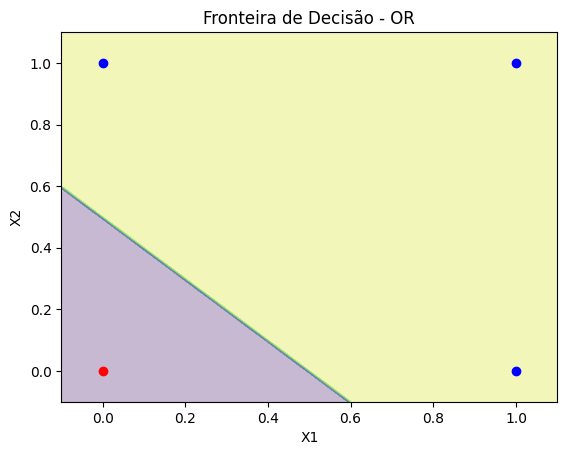

In [ ]:
# Mostrando para AND e OR na qual são problemas linearmente separaveis
for label, y in zip(['AND', 'OR'], [y_and, y_or]):
    perceptron = Perceptron(tamanho_input=2)
    perceptron.train(X, y)
    print(f"\nPerceptron para {label}:")
    for xi in X:
        print(f"Entrada: {xi}, Saída: {perceptron.predict(xi)}")
    plot_decision_boundary(perceptron, X, y, f"Fronteira de Decisão - {label}")


Perceptron para XOR:
Entrada: [0 0], Saída: 0
Entrada: [0 1], Saída: 0
Entrada: [1 0], Saída: 0
Entrada: [1 1], Saída: 0


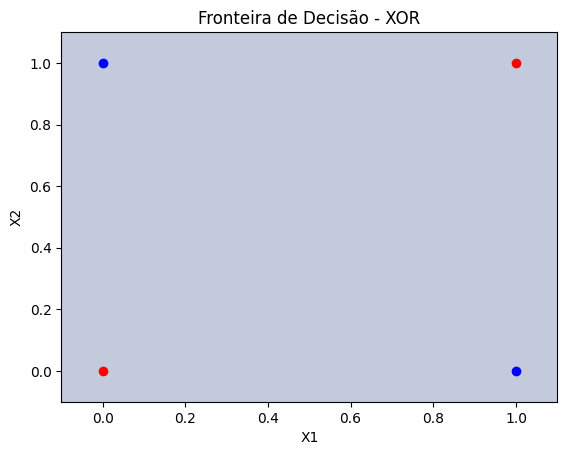

In [ ]:
# Mostrando para XOR na qual não é um problema linearmente separavel
for label, y in zip(['XOR'], [y_xor]):
    perceptron = Perceptron(tamanho_input=2)
    perceptron.train(X, y)
    print(f"\nPerceptron para {label}:")
    for xi in X:
        print(f"Entrada: {xi}, Saída: {perceptron.predict(xi)}")
    plot_decision_boundary(perceptron, X, y, f"Fronteira de Decisão - {label}")

In [ ]:
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML 

class PerceptronAnimado:
  """
  Definição da classe PerceptronAnimado.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  def __init__(self, tamanho_input, learning_rate=0.1):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
    """
    self.wi = np.zeros(tamanho_input)
    self.bias = 0
    self.learning_rate = learning_rate
    self.historico_pesos = []

  def predict(self, x):
    """
    Função: predict
    Descrição: Utiliza o estado atual do modelo (pesos treinados) para realizar predições sobre novos dados de entrada, retornando a classe ou valor estimado.
  """
    val = np.dot(self.wi, x) + self.bias
    return 1 if val > 0 else -1

  def train_step(self, X, y):
    """
    Função: train_step
    Descrição: Função responsável por executar a lógica de train_step dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
    """
    erro_na_epoca = False
    for xi, yi in zip(X, y):
        y_chapeu = self.predict(xi)
        if y_chapeu != yi:
            self.wi = self.wi + self.learning_rate * yi * xi
            self.bias = self.bias + self.learning_rate * yi
            erro_na_epoca = True
            self.historico_pesos.append((self.wi.copy(), self.bias))
    return erro_na_epoca

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([-1, -1, -1, 1])

modelo = PerceptronAnimado(tamanho_input=2)
for _ in range(20):
    if not modelo.train_step(X, y):
        break

fig, ax = plt.subplots(figsize=(8, 6))
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

def update(frame):
  """
  Função: update
  Descrição: Função auxiliar usada para atualizar a posição do ponto no gráfico de visualização durante a animação da convergência.
  """
  ax.clear()
  weights, bias = modelo.historico_pesos[frame]

  for xi, yi in zip(X, y):
      ax.scatter(xi[0], xi[1], color='red' if yi == -1 else 'blue', s=100)

  if weights[1] != 0:
      x_vals = np.array([x_min, x_max])
      y_vals = -(weights[0] * x_vals + bias) / weights[1]
      ax.plot(x_vals, y_vals, '--k', label=f'Iteração {frame+1}')
      ax.fill_between(x_vals, y_vals, y_max, color='blue', alpha=0.1)
      ax.fill_between(x_vals, y_min, y_vals, color='red', alpha=0.1)

  ax.set_xlim(x_min, x_max)
  ax.set_ylim(y_min, y_max)
  ax.set_title(f"Aprendizado do Perceptron (Iteração {frame+1})\nPesos: {weights}, Bias: {bias:.2f}")
  ax.grid(True, linestyle='--', alpha=0.6)

ani = FuncAnimation(fig, update, frames=len(modelo.historico_pesos), repeat=True, interval=800)
plt.close()
HTML(ani.to_jshtml())

## Perceptron Moderno - Resolvendo Problema XOR

Perceptron moderno pode ser visto como:

$$\hat{y} = \sigma(\sum_{i = 1}^n x_iw_i + b)$$

Em que $\sigma$ é uma função de ativação. Para esse problema como temos saida que vão de -1 a +1 vamos usar a função de ativação tangente hiperbólica que é definida como:

$$
Tanh(x) = \frac{senh(x)}{cosh(x)} = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

In [ ]:
class MLP:
  """
  Definição da classe MLP.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  def __init__(self, tamanho_input, tamanho_hidden=1, learning_rate=0.1, epocas=1000):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
  """
    self.wi_hidden = np.random.randn(tamanho_hidden, tamanho_input)  # Pesos camada oculta
    self.bi_hidden = np.zeros(tamanho_hidden)  # Bias camada oculta
    self.wi_output = np.random.randn(1, tamanho_hidden)  # Pesos camada de saída
    self.bi_output = np.zeros(1)  # Bias camada de saída
    self.lr = learning_rate
    self.epocas = epocas

  def tanh(self, x):
    """
    Função: tanh
    Descrição: Função Tangente Hiperbólica. Comprime os valores de entrada no intervalo entre -1 e 1, sendo centrada em zero.
    """
    return np.tanh(x)

  def tanh_deriv(self, x): # Derivada da Tangente Hiperpólica
    """
    Função: tanh_deriv
    Descrição: Função responsável por executar a lógica de tanh_deriv dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
    """
    return 1 - np.tanh(x)**2

  def forward(self, x):
    """
    Função: forward
    Descrição: Define o fluxo de dados (forward pass) através das camadas da rede, processando a entrada para gerar as predições ou logits de saída.
    """
    z1 = np.dot(self.wi_hidden, x) + self.bi_hidden
    h = self.tanh(z1)

    z2 = np.dot(self.wi_output, h) + self.bi_output
    y_chapeu = self.tanh(z2)

    return z1, h, z2, y_chapeu

  def predict(self, x):
    """
    Função: predict
    Descrição: Utiliza o estado atual do modelo (pesos treinados) para realizar predições sobre novos dados de entrada, retornando a classe ou valor estimado.
    """
    z1, h, z2, y_hat = self.forward(x)
    if y_hat >= 0:
        return 1
    else:
        return -1

  def train(self, X, y):
    """
    Função: train
    Descrição: Implementa o laço principal de treinamento, onde o modelo ajusta seus parâmetros iterativamente com base no erro calculado sobre os dados.
    """
    for _ in range(self.epocas):
      for xi, yi in zip(X, y):
        ## Forward
        z1, h, z2, y_hat = self.forward(xi)

        ## Backward -> Calculados as Derivadas utilizando regra da Cadeia
        # saida
        error = y_hat - yi # No caso do mse Loss é 1/2*(y - y_hat)^2 a derivada é simplesmente (y-y_hat)
        delta_output = error * self.tanh_deriv(z2) # Usando regra da cadeia multiplicamos a derivada da saida pela derivada da função de ativação

        # camada oculta
        delta_hidden = np.dot(self.wi_output.T, delta_output) * self.tanh_deriv(z1) # Mesma coisa, apenas utilizando regra da cadeia e as regras de derivada

        # Calculando Gradientes
        dw_output = np.outer(delta_output, h.T)
        db_output = delta_output

        dw_hidden = np.outer(delta_hidden, xi.T)
        db_hidden = delta_hidden

        # Atualizando
        self.wi_output -= self.lr * dw_output
        self.bi_output -= self.lr * db_output

        self.wi_hidden -= self.lr * dw_hidden
        self.bi_hidden -= self.lr * db_hidden


Perceptron para XOR:
Entrada: [0 0], Saída: -1
Entrada: [0 1], Saída: -1
Entrada: [1 0], Saída: 1
Entrada: [1 1], Saída: -1


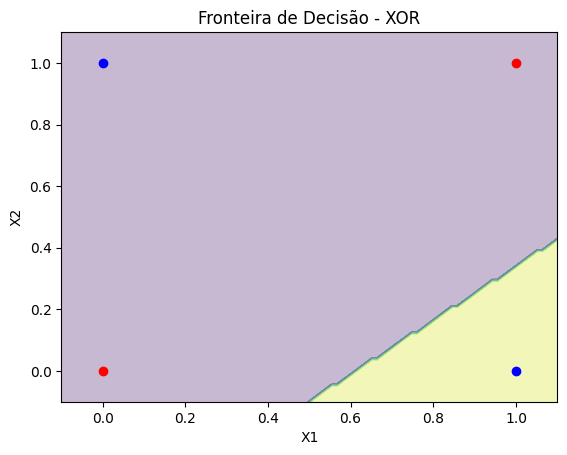

In [ ]:
for label, y in zip(['XOR'], [y_xor]):
  mlp = MLP(tamanho_input=2, tamanho_hidden=1)
  mlp.train(X, y)
  print(f"\nPerceptron para {label}:")
  for xi in X:
      print(f"Entrada: {xi}, Saída: {mlp.predict(xi)}")
  plot_decision_boundary(mlp, X, y, f"Fronteira de Decisão - {label}")


Perceptron para XOR:
Entrada: [0 0], Saída: -1
Entrada: [0 1], Saída: 1
Entrada: [1 0], Saída: 1
Entrada: [1 1], Saída: -1


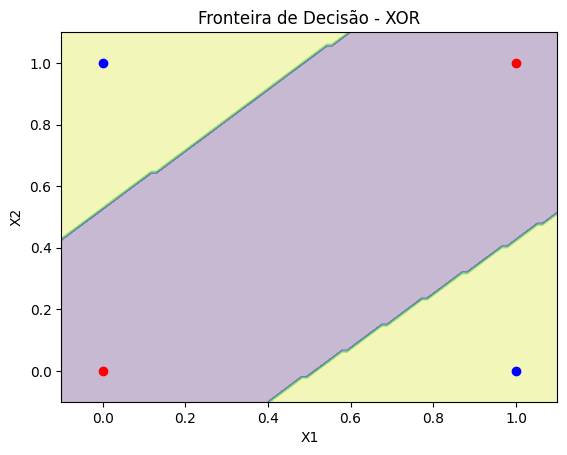

In [ ]:
# Na maioria dos casos 2 ainda é pouco, mas é possível, contudo nem sempre
# vai convergir para resolver o problema. Por isso em geral usamos mais neurônios
for label, y in zip(['XOR'], [y_xor]):
  mlp = MLP(tamanho_input=2, tamanho_hidden=2, epocas=2000)
  mlp.train(X, y)
  print(f"\nPerceptron para {label}:")
  for xi in X:
      print(f"Entrada: {xi}, Saída: {mlp.predict(xi)}")
  plot_decision_boundary(mlp, X, y, f"Fronteira de Decisão - {label}")


Perceptron para XOR:
Entrada: [0 0], Saída: -1
Entrada: [0 1], Saída: 1
Entrada: [1 0], Saída: 1
Entrada: [1 1], Saída: -1


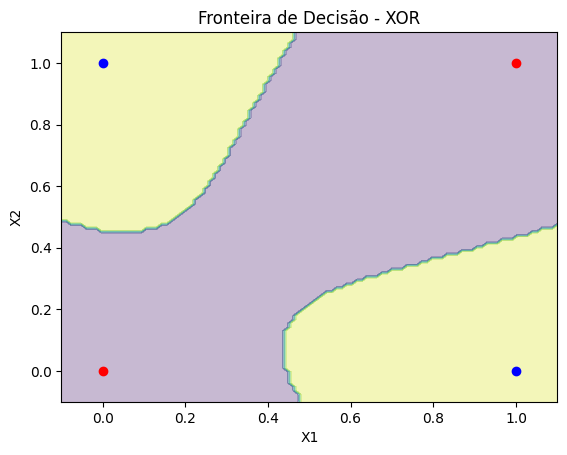

In [ ]:
for label, y in zip(['XOR'], [y_xor]):
  mlp = MLP(tamanho_input=2, tamanho_hidden=3, epocas=2000)
  mlp.train(X, y)
  print(f"\nPerceptron para {label}:")
  for xi in X:
      print(f"Entrada: {xi}, Saída: {mlp.predict(xi)}")
  plot_decision_boundary(mlp, X, y, f"Fronteira de Decisão - {label}")